In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
path = "datasets/global_bleaching_environmental.csv"
df = pd.read_csv(path, low_memory=False, na_values=["nd", "ND", ""])

In [6]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

numeric_cols = [
    "Percent_Bleaching", "Temperature_Mean", "SSTA", "TSA",
    "Depth_m", "Latitude_Degrees", "Longitude_Degrees", "Cyclone_Frequency"
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print(df.shape)
display(df.head())
display(df[numeric_cols].describe())

(41361, 62)


,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,...,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,NaN,Tropical Atlantic,Cuba and Cayman Islands,Cuba,...,5.0,0.0,0.00,0.74,7.25,0.18,2005-09-15,NaN,NaN,NaN
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,NaN,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,...,4.0,0.0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,NaN
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,...,7.0,0.0,0.00,1.04,11.66,0.26,2006-01-15,NaN,NaN,NaN
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,4.0,0.0,0.00,0.75,5.64,0.20,2006-04-15,NaN,NaN,NaN
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,5.0,0.0,0.00,0.92,6.89,0.25,2006-04-15,NaN,NaN,NaN


,Percent_Bleaching,Temperature_Mean,SSTA,TSA,Depth_m,Latitude_Degrees,Longitude_Degrees,Cyclone_Frequency
count,34515.000000,41229.000000,41213.000000,41213.000000,39562.000000,41361.000000,41361.000000,41361.000000
mean,9.619465,300.410472,0.254942,-0.980981,6.922119,7.558085,34.966127,52.159650
std,20.190956,1.578528,0.829508,1.640874,4.162464,15.732185,103.404598,7.589593
min,0.000000,290.880000,-4.620000,-11.970000,0.000000,-30.262500,-179.974300,18.310000
25%,0.000000,299.740000,-0.250000,-1.810000,3.700000,-4.902500,-78.385600,47.940000
50%,0.250000,300.760000,0.240000,-0.740000,6.000000,10.776100,96.843300,50.920000
75%,6.000000,301.640000,0.750000,0.100000,10.000000,20.050500,120.880400,55.730000
max,100.000000,303.520000,5.900000,5.900000,90.000000,36.750000,179.964500,105.800000


## 1) Bleaching distribution

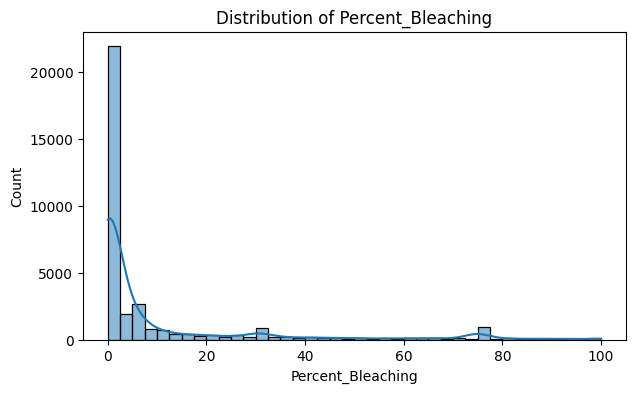

In [7]:
plt.figure(figsize=(7,4))
sns.histplot(df["Percent_Bleaching"], bins=40, kde=True)
plt.title("Distribution of Percent_Bleaching")
plt.show()

## 2) Bleaching by ocean

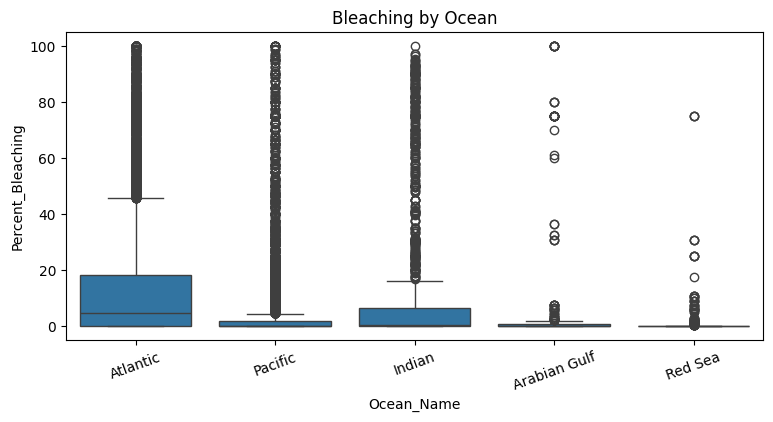

In [8]:
plt.figure(figsize=(9,4))
top_oceans = df["Ocean_Name"].value_counts().head(6).index
sns.boxplot(data=df[df["Ocean_Name"].isin(top_oceans)],
            x="Ocean_Name", y="Percent_Bleaching")
plt.xticks(rotation=20)
plt.title("Bleaching by Ocean")
plt.show()

## 3) Yearly mean

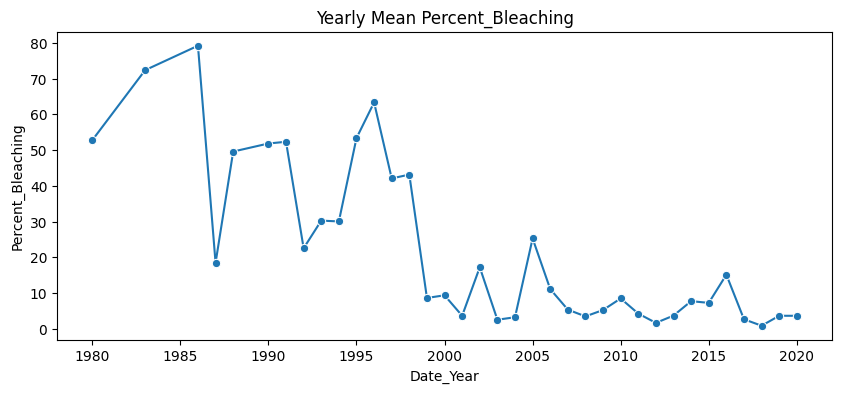

In [9]:
yearly = df.groupby("Date_Year", as_index=False)["Percent_Bleaching"].mean()
plt.figure(figsize=(10,4))
sns.lineplot(data=yearly, x="Date_Year", y="Percent_Bleaching", marker="o")
plt.title("Yearly Mean Percent_Bleaching")
plt.show()

## 4) Correlation with environmental variables

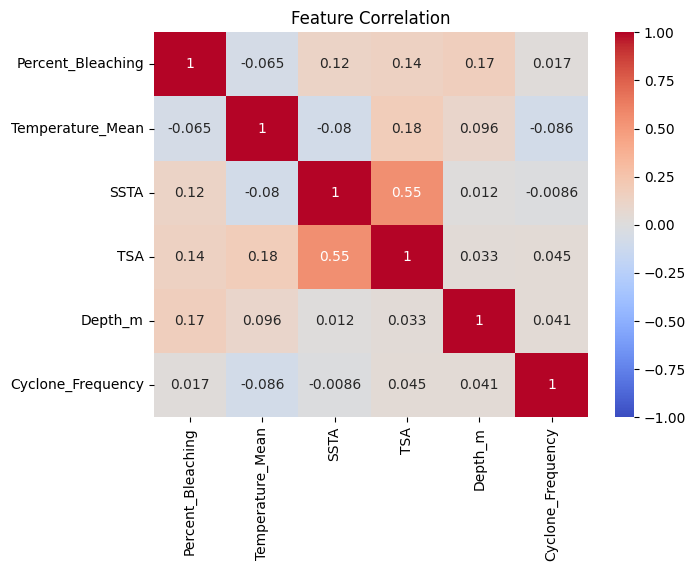

In [10]:
corr_cols = ["Percent_Bleaching","Temperature_Mean","SSTA","TSA","Depth_m","Cyclone_Frequency"]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation")
plt.show()


## 5) Spatial pattern

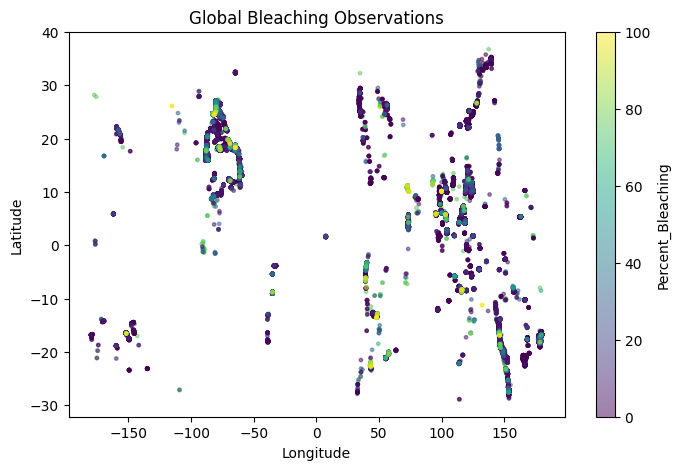

In [11]:
plt.figure(figsize=(8,5))
sc = plt.scatter(df["Longitude_Degrees"], df["Latitude_Degrees"],
                 c=df["Percent_Bleaching"], s=6, alpha=0.5, cmap="viridis")
plt.colorbar(sc, label="Percent_Bleaching")
plt.title("Global Bleaching Observations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()